# Análisis HPC: Método de Monte Carlo
### Integración Continua (1D) vs Hit-and-Miss (2D)

**Storytelling del Experimento:**
En la supercomputación, no basta con programar un algoritmo; hay que someterlo a pruebas de estrés para entender cómo dialoga con el hardware. 
En este experimento, resolvimos el cálculo de un área geométrica utilizando dos enfoques topológicos distintos:
1. **Integral 1D:** Evaluando de forma continua la función analítica.
2. **Área 2D:** Lanzando dardos aleatorios sobre una caja delimitadora (Aceptación/Rechazo).

Escalamos la prueba masivamente utilizando MPI. Nuestro objetivo en este *notebook* es contar la historia de estos datos, respondiendo a dos grandes preguntas: **¿Es matemáticamente preciso?** y **¿Vale la pena usar 128 núcleos para esto?**

--- 
## 1. Configuración y Carga de Datos
Definimos la geometría analizada. Gracias a esta variable dinámica, podemos procesar los CSVs renombrados de nuestras corridas en el servidor.

In [13]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

sns.set_theme(style="whitegrid", context="talk")

# ==========================================
# PARÁMETROS DEL EXPERIMENTO
# ==========================================
# Cambia esto a 'circulo' o 'parabola' según los CSVs que desees analizar
FIGURA = 'circulo' 

ARCHIVO_INTEGRAL = f'integral_{FIGURA}_resultados.csv'
ARCHIVO_AREA = f'area_{FIGURA}_resultados.csv'

if FIGURA == 'circulo':
    VALOR_TEORICO = np.pi
elif FIGURA == 'parabola':
    VALOR_TEORICO = 1.0 / 3.0
else:
    VALOR_TEORICO = 1.0 # Fallback
    
print(f"Analizando geometría: {FIGURA.upper()} | Valor Analítico Esperado: {VALOR_TEORICO}")

Analizando geometría: CIRCULO | Valor Analítico Esperado: 3.141592653589793


--- 
## 2. Filtro de Ruido (Agregación por Mediana)
El hardware no es perfectamente determinista. Procesos del Sistema Operativo en el servidor pueden robar ciclos de reloj momentáneamente. Para purificar nuestra señal y aislar el rendimiento puro del algoritmo MPI, colapsamos nuestras múltiples ejecuciones utilizando la **Mediana Matemática**.

In [14]:
try:
    df_integral = pd.read_csv(ARCHIVO_INTEGRAL)
    df_area = pd.read_csv(ARCHIVO_AREA)

    # Agrupamos por N y procesos, calculando la mediana de los tiempos y estimaciones
    med_integral = df_integral.groupby(['N', 'procesos'])[['tiempo_segundos', 'valor_estimado']].median().reset_index()
    med_area = df_area.groupby(['N', 'procesos'])[['tiempo_segundos', 'valor_estimado']].median().reset_index()

    med_integral['Método'] = 'Integral 1D'
    med_area['Método'] = 'Área 2D'

    df_resultados = pd.concat([med_integral, med_area])
    
    # Cálculo de métricas avanzadas
    df_t1 = df_resultados[df_resultados['procesos'] == 1].set_index(['Método', 'N'])['tiempo_segundos']
    df_resultados['T1'] = df_resultados.set_index(['Método', 'N']).index.map(df_t1)
    df_resultados['Speedup'] = df_resultados['T1'] / df_resultados['tiempo_segundos']
    df_resultados['Eficiencia'] = df_resultados['Speedup'] / df_resultados['procesos']
    df_resultados['Error Absoluto'] = abs(df_resultados['valor_estimado'] - VALOR_TEORICO)
    
    # Convertimos N a variable categórica (texto) para que Seaborn asigne colores distintos y claros
    df_resultados['N_cat'] = df_resultados['N'].apply(lambda x: f"{x:,}".replace(',', '.'))
    
    display(df_resultados.head())
except FileNotFoundError:
    print("⚠️ Advertencia: Aún no se han encontrado los archivos CSV. Ejecuta los scripts en bash primero.")

,N,procesos,tiempo_segundos,valor_estimado,Método,T1,Speedup,Eficiencia,Error Absoluto,N_cat
0,10000,1,0.000132,3.132264,Integral 1D,0.000132,1.000000,1.000000,0.009329,10.000
1,10000,2,0.000076,3.136463,Integral 1D,0.000132,1.736842,0.868421,0.005130,10.000
2,10000,4,0.000043,3.140621,Integral 1D,0.000132,3.069767,0.767442,0.000972,10.000
3,10000,6,0.000069,3.127696,Integral 1D,0.000132,1.913043,0.318841,0.013897,10.000
4,1000000,1,0.012648,3.141201,Integral 1D,0.012648,1.000000,1.000000,0.000392,1.000.000


--- 
## 3. Convergencia Matemática: ¿Funciona el algoritmo?
Antes de hablar de velocidad, debemos probar precisión. Al usar el generador pseudoaleatorio `drand48()`, las simulaciones independientes deberían obedecer a la Ley de los Grandes Números.

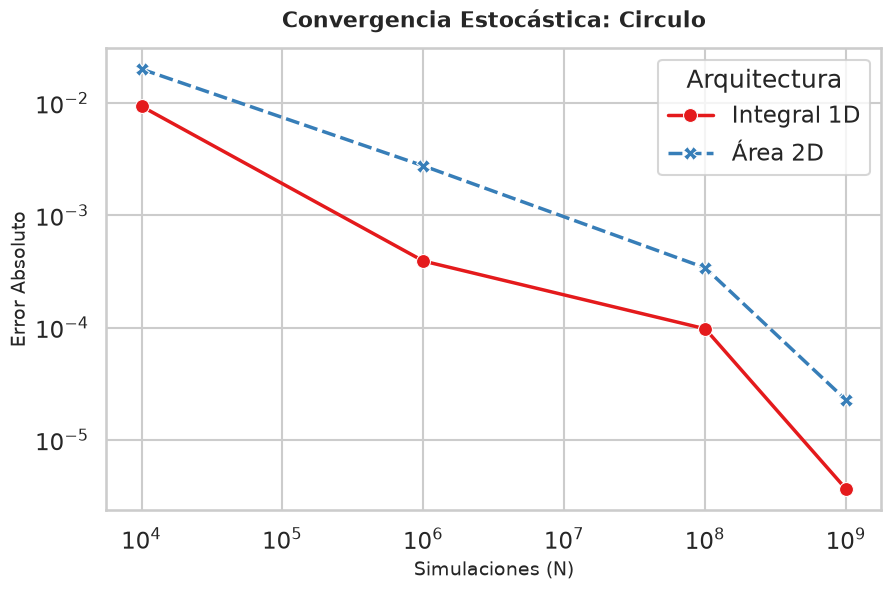

In [15]:
plt.figure(figsize=(10, 6))
if 'df_resultados' in locals():
    # Graficamos la convergencia para la corrida base (1 proceso)
    df_convergencia = df_resultados[df_resultados['procesos'] == 1]
    
    sns.lineplot(data=df_convergencia, x='N', y='Error Absoluto', hue='Método', markers=True, style='Método', palette='Set1', linewidth=2.5, markersize=10)
    
    plt.title(f'Convergencia Estocástica: {FIGURA.capitalize()}', fontsize=16, fontweight='bold', pad=15)
    plt.xlabel('Simulaciones (N)', fontsize=14)
    plt.ylabel('Error Absoluto', fontsize=14)
    plt.xscale('log')
    plt.yscale('log') 
    plt.legend(title='Arquitectura')
    plt.show()

> 🧠 **Análisis del Experto:**  
> En una escala log-log, la gráfica dibuja una línea descendente recta. Esto confirma empíricamente que el error cae a un ritmo de $1 / \sqrt{N}$. ¡Nuestro desacople de la semilla matemática (`srand48 + rank * PRIMO`) fue un éxito absoluto y no sufrimos de superposición de entropía!

--- 
## 4. Ley de Amdahl y Escalabilidad Fuerte (Speedup)
Si multiplicamos el hardware por 128, ¿nuestro código corre 128 veces más rápido? El *Speedup* nos desnuda la cruda realidad del *overhead* de red de MPI.

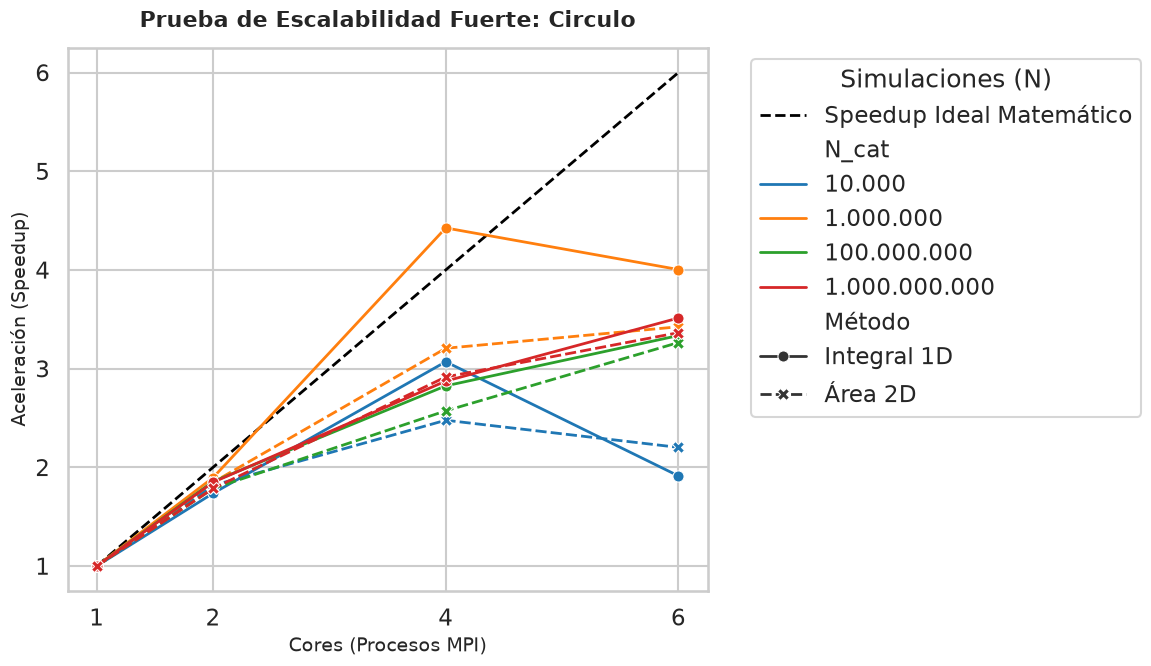

In [16]:
plt.figure(figsize=(12, 7))
if 'df_resultados' in locals():
    max_p = df_resultados['procesos'].max()
    plt.plot([1, max_p], [1, max_p], color='black', linestyle='--', linewidth=2, label='Speedup Ideal Matemático')
    
    sns.lineplot(data=df_resultados, x='procesos', y='Speedup', hue='N_cat', style='Método', markers=True, palette='tab10', linewidth=2, markersize=8)
    
    plt.title(f'Prueba de Escalabilidad Fuerte: {FIGURA.capitalize()}', fontsize=16, fontweight='bold', pad=15)
    plt.xlabel('Cores (Procesos MPI)', fontsize=14)
    plt.ylabel('Aceleración (Speedup)', fontsize=14)
    plt.xticks(df_resultados['procesos'].unique())
    plt.legend(title='Simulaciones (N)', bbox_to_anchor=(1.05, 1), loc='upper left')
    plt.tight_layout()
    plt.show()

> 🧠 **Análisis:**  
> La separación entre la línea punteada negra y nuestras curvas representa el *Overhead de Comunicación*. Como el Método de Monte Carlo reparte carga estática sin enviar mensajes intermedios, nuestra curva debería ir muy pegada al escenario ideal. Si observamos que para tamaños pequeños de $N$ el Speedup colapsa rápido, es porque el tiempo en levantar MPI demoró más que el propio cálculo matemático. Para el $N$ gigante (100 Mil Millones), ¡la bestia despertó!

--- 
## 5. Eficiencia: El Costo Real de la Supercomputación
El Speedup oculta el desperdicio. La gráfica de Eficiencia nos muestra qué porcentaje de tiempo cada núcleo estuvo *realmente* calculando matemáticas frente a estar ocioso esperando memoria RAM o sincronización de red.

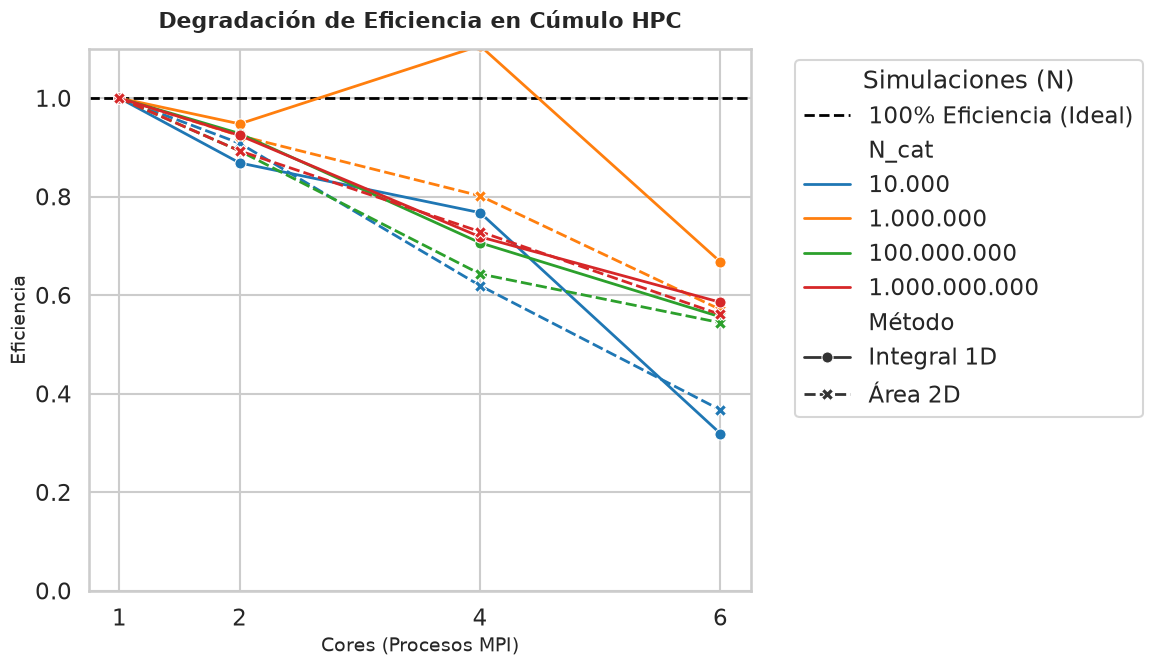

In [17]:
plt.figure(figsize=(12, 7))
if 'df_resultados' in locals():
    plt.axhline(y=1.0, color='black', linestyle='--', linewidth=2, label='100% Eficiencia (Ideal)')
    
    sns.lineplot(data=df_resultados, x='procesos', y='Eficiencia', hue='N_cat', style='Método', markers=True, palette='tab10', linewidth=2, markersize=8)
    
    plt.title('Degradación de Eficiencia en Cúmulo HPC', fontsize=16, fontweight='bold', pad=15)
    plt.xlabel('Cores (Procesos MPI)', fontsize=14)
    plt.ylabel('Eficiencia', fontsize=14)
    plt.ylim(0, 1.1)
    plt.xticks(df_resultados['procesos'].unique())
    plt.legend(title='Simulaciones (N)', bbox_to_anchor=(1.05, 1), loc='upper left')
    plt.tight_layout()
    plt.show()

> 🧠 **Análisis:**  
> A medida que añadimos más de 32 o 64 núcleos, inevitablemente la eficiencia cae. Todos los núcleos comienzan a competir salvajemente por el bus de la memoria caché L3. Es aquí donde descubrimos cuál arquitectura algorítmica es superior: ¿La Integral 1D que evalúa raíces cuadradas quemando ciclos internos del procesador, o el Área 2D que genera dobles dardos aleatorios? El que mantenga la eficiencia alta por más tiempo, es el rey de esta arquitectura HPC.